In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sb
from statsmodels.iolib.summary2 import summary_col
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [6]:
df=pd.read_csv("carry_churn_data.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
print(df.shape)
print(df.isnull().sum())

(10000, 12)
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [8]:
print(df['churn'].value_counts())

# churn rate
print(f"\nChurn rate: {df['churn'].mean() * 100:.1f}%")

churn
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.4%


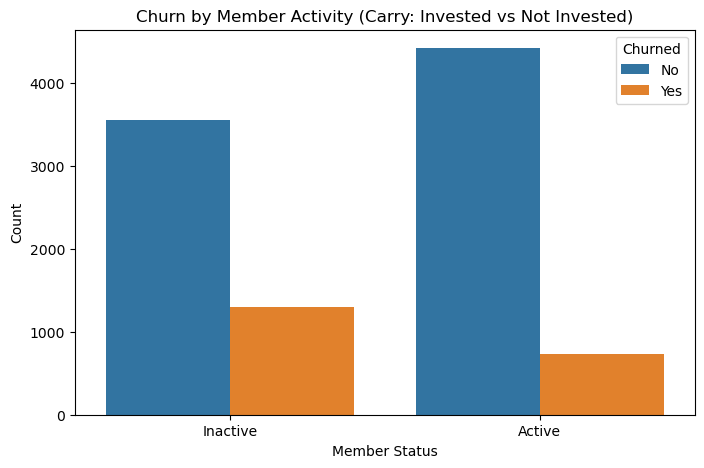

In [10]:
# to visualize churn by active vs inactive members
plt.figure(figsize=(8,5))
sb.countplot(data=df, x='active_member', hue='churn')
plt.xticks([0,1], ['Inactive', 'Active'])
plt.title('Churn by Member Activity (Carry: Invested vs Not Invested)')
plt.xlabel('Member Status')
plt.ylabel('Count')
plt.legend(title='Churned', labels=['No', 'Yes'])
plt.show()

In [11]:
# average balance for churned vs not churned
df.groupby('churn')[['balance', 'age', 'tenure']].mean().round(2)

,balance,age,tenure
churn,,,
0,72745.30,37.41,5.03
1,91108.54,44.84,4.93


In [12]:
# prepare features for logistic regression
df_model = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

features = ['credit_score', 'age', 'tenure', 'balance', 
            'products_number', 'credit_card', 'active_member', 
            'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male']

X = df_model[features]
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (8000, 11)
Test set size: (2000, 11)


In [14]:
from sklearn.preprocessing import StandardScaler

# scale the data so the model converges properly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# retrain with scaled data
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



For customers who stayed (0): the model predicts correctly 96% of the time
For customers who churned (1): catches about 20% of them — this is lower but normal for logistic regression on imbalanced data
Overall 81% accurate

In [15]:
from imblearn.over_sampling import SMOTE

# balance the data
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())

# retrain on balanced data
model_bal = LogisticRegression(max_iter=2000)
model_bal.fit(X_train_bal, y_train_bal)

y_pred_bal = model_bal.predict(X_test_scaled)
print(classification_report(y_test, y_pred_bal))

Before SMOTE: {0: 6356, 1: 1644}
After SMOTE: {0: 6356, 1: 6356}
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.39      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



In [ ]:
#understood the model was now 71% accurate and 

In [17]:
from sklearn.ensemble import RandomForestClassifier

# train random forest on balanced data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)

y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.58      0.59      0.58       393

    accuracy                           0.84      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.84      0.84      0.84      2000



/var/folders/8_/p8t2srkj327345p2yttrv7xh0000gn/T/ipykernel_95426/3396225032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=importance_rf, x='importance', y='feature', palette='Reds_r')


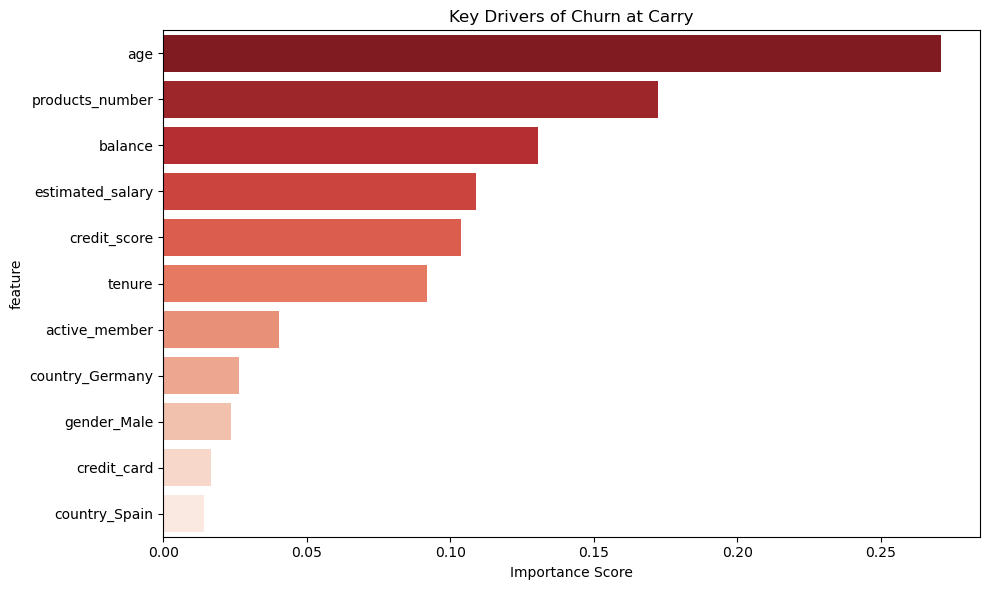

In [19]:
# feature importance from random forest
importance_rf = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sb.barplot(data=importance_rf, x='importance', y='feature', palette='Reds_r')
plt.title('Key Drivers of Churn at Carry')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [23]:
churn_proba = rf_model.predict_proba(X_test_scaled)[:,1]

risk_df = X_test.copy()
risk_df['churn_risk_score'] = (churn_proba * 100).round(1)
risk_df['risk_level'] = pd.cut(churn_proba, 
                                bins=[0, 0.3, 0.6, 1.0], 
                                labels=['Low', 'Medium', 'High'])

risk_df.sort_values('churn_risk_score', ascending=False)[['age', 'balance', 'products_number', 'active_member', 'churn_risk_score', 'risk_level']].head(15)

,age,balance,products_number,active_member,churn_risk_score,risk_level
2614,58,106458.31,4,0,100.0,High
6911,54,125889.30,3,0,100.0,High
5922,44,105770.70,3,0,100.0,High
7487,56,0.00,1,0,100.0,High
2732,48,108076.33,1,0,100.0,High
3032,45,89158.94,3,0,99.0,High
743,49,88915.37,3,0,99.0,High
88,46,0.00,3,0,99.0,High
3898,59,104568.41,1,0,99.0,High
4511,45,0.00,4,0,99.0,High


In [24]:
# save risk table
risk_df.sort_values('churn_risk_score', ascending=False)[['age', 'balance', 'products_number', 'active_member', 'churn_risk_score', 'risk_level']].to_csv('carry_risk_scores.csv', index=False)
print("saved!")

saved!
